Rough vol Calibration
---

In [1]:
# Downloading the needed libraries
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import time
from diffrax import *
import pandas as pd
import scipy.signal as signal
import scipy.special as special
from scipy.optimize import minimize
from scipy.optimize import bisect
from scipy.stats import norm
from scipy.stats import multivariate_normal
from concurrent.futures import ProcessPoolExecutor
num_processes = 8  # Adjust based on your machine's CPU cores and task requirements



# Importing the other codes we need
from controls import *
from hybrid_joint import *
from Jackels import impliedVolJaeckelRational
%matplotlib inline


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.9/site-pack

AttributeError: _ARRAY_API not found

Quadratic rough Heston model - RDE version

$$ \begin{cases}\mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \\ \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t \end{cases} $$

with $\theta$ some function chosen to match the VIX futures? Check this is the same as solving $V$ first and then taking the exponential martingale.

$$S_t =S_0 \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$


In [2]:
class RDE_QuadHeston:
    
    def __init__(self, grid_points, epsilon, M, T, H,S0):
        """
        grid_points: number of points in the simulation grid
        epsilon: time step?
        H: Hurst parameter
        M: number of paths to simulate
        T: time horizon
        """
        self.S0=S0
        self.epsilon = 1/grid_points #epsilon
        # smaller time step
        self.solver_epsilon = 0.02*self.epsilon
        # lag (it has to be slightly bigger than the time step)
        self.lag = 1.2*self.epsilon
        self.grid_points = grid_points
        self.M, self.T, self.H = M, T, H
        # kappa parameter for the Hybrid scheme
        self.kappa = 1
        
        # create the time grid (over the time horizon 1)
        self.times = jnp.arange(0., 1., self.epsilon)
        # every point x in the grid is approximated with the closest lower integer to x*eps
        # needed for the subsampling
        self.every_nth_pt = int(self.grid_points*self.epsilon)
        


    def run__init__(self):        
        args = (self.grid_points, self.T, self.kappa)
        num_processes = 8  # Adjust based on your machine's CPU cores and task requirements
        
        with ProcessPoolExecutor(max_workers=num_processes) as executor:
            self.futures = [executor.submit(degenerate_fbm_1_bm_1_bm_wrapper, args) for _ in range(self.M)]
            self.results = [future.result() for future in self.futures]

        self.list_fbm, self.list_bm1, self.list_bm2 = zip(*self.results)

        self.stacked_fbm = jnp.stack(self.list_fbm).T
        self.stacked_bm1 = jnp.stack(self.list_bm1).T
        self.stacked_bm2 = jnp.stack(self.list_bm2).T
        
        self.bm1_interp = LinearInterpolation(self.times, self.stacked_bm1)
        self.bm2_interp = LinearInterpolation(self.times, self.stacked_bm2)
        self.fbm_interp = LinearInterpolation(self.times, self.stacked_fbm)

        self.bm1_control = evaluate_and_reshape(self.bm1_interp.evaluate)
        self.bm2_control = evaluate_and_reshape(self.bm2_interp.evaluate)
        self.fbm_control = evaluate_and_reshape(self.fbm_interp.evaluate)
        
        self.fbm_fun = lambda t: self.fbm_interp.evaluate(0,t)
        self.fbm_lagged_control_temp = lagged_control(self.fbm_fun, self.lag)
        self.fbm_lagged_control = lambda s,t: self.fbm_lagged_control_temp(s,t).reshape(1, self.M)
        
        self.bm_control = stack_controls(self.bm1_control, self.bm2_control)
        self.lead_lag_control = stack_controls(self.fbm_lagged_control, self.bm_control)
            
    def run_paths_RDE_QuadHeston(self, params):
        """
        params, bm_interp, lagged_fbm_control 
        """
        # define the SDE
        # these parameters could be put inside the args of drift and diffusion
        # a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,0.1,1.
        a, b, c, theta, lam, eta = params

        saveat = SaveAt(ts = self.times)

        # the drift, diffusion and initial condition of the RDE. 
        # This can be changed to any other RDE. In particular, if one wants the vol to be
        # driven by a single noise, just set the corresponding term in the vector field to zero
        y0 = jnp.array([1, 1])
        drift = lambda t, y, args: jnp.array([-(1/2) * y[0]*( a * jnp.square(y[1] - b) + c ), lam * (theta - y[1])])
        diffusion = lambda t, y, args: jnp.array([[0, 0, y[0]*jnp.sqrt(a * jnp.square(y[1] - b) + c)],[lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ), 0, 0]])

        solutions = vmap_batch_fbm_solve(jnp.arange(self.M), self.lead_lag_control, drift, diffusion, y0, Midpoint(), 0, 1, self.solver_epsilon, saveat)

        return solutions
    
    
    
    def callPrice_RDE_QuadHeston_MC(self, params, strikes):
        """
        params: parameters
        payoff_function: Payoff function for which we want to compute prices under quadRHeston
        """
        
        # compute integral price and expo martingale for the traj
        exp_martingale_T = self.run_paths_RDE_QuadHeston(params).ys[:, -1, 0]#num cammino, tempi, index
        times = self.run_paths_RDE_QuadHeston(params).ts[0,:] 
        Call_prices=[jnp.mean(jnp.maximum(self.S0*exp_martingale_T - K,0)) for K in strikes]
        
        return Call_prices
    


    def implied_vol(self, params, strikes):
        cps = self.callPrice_RDE_QuadHeston_MC(params, strikes)
        return [impliedVolJaeckelRational(self.S0, K, c, self.T) for (K,c) in zip(strikes, cps)]



## Numerical tests

In [3]:
H, kappa, M = 0.1, 1, 1000
S0 = 179.83
grid_points = 100
T = 1.
# Model parameters
a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,0.1,1.
params = a, b, c, theta, lam, eta

epsilon = 0.01

In [4]:
nbStrikes = 30
grid_points = 300
nbPaths = 30000
grid = np.linspace(0,T,grid_points)

strikes = np.linspace(S0*np.exp(-0.4), S0*np.exp(0.4), nbStrikes)
log_moneyness = np.log(strikes/S0)

### One-path example

SDE simulation computation time:  1.1440150737762451


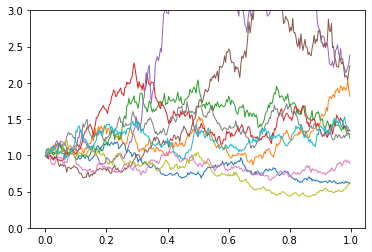

In [5]:
rde = RDE_QuadHeston(grid_points, epsilon, M, T, H,S0)
rde.run__init__()


#############################
t0 = time.time()
traj=rde.run_paths_RDE_QuadHeston(params)
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

# Assuming M and solutions are defined
for k in range(10):
    # Plot using the next color in the default cycle
    plt.plot(traj.ts[0, :], traj.ys[k, :, 0],linewidth=1)

plt.ylim(0, 3)
plt.show()

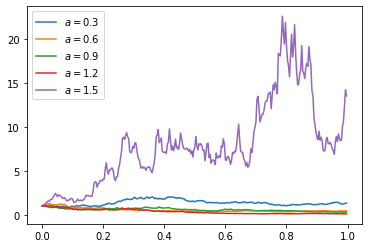

In [6]:
for a in np.linspace(.3, 1.5, 5):
    params = a, b, c, theta, lam, eta
    rde = RDE_QuadHeston(grid_points, epsilon, M, T, H,S0)
    rde.run__init__()
    exp_martingale = rde.run_paths_RDE_QuadHeston(params).ys[1, :, 0]#num cammino, tempi, index
    times = rde.run_paths_RDE_QuadHeston(params).ts[0,:] 
    plt.plot(times, exp_martingale, label=r'$a=$%.1f' %a)
plt.legend(loc="best")
plt.show()

## Run Monte Carlo computations for option prices

In [7]:
a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,0.1, 1.#1., 0.5, 1., 2., 0.2, 0.4
params = a, b, c, theta, lam, eta

In [8]:
strike = [0.]

#############################
t0 = time.time()
print(rde.callPrice_RDE_QuadHeston_MC(params,strike))
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time)
#############################

[Array(178.47142, dtype=float32)]
SDE simulation computation time:  2.218632936477661


In [9]:
Call_prices = rde.callPrice_RDE_QuadHeston_MC(params, strikes)
dtCalls = time.time() - t0
print("Computation time: ", dtCalls)
print("Prices: ", Call_prices)

Computation time:  7.78914999961853
Prices:  [Array(67.9517, dtype=float32), Array(64.66178, dtype=float32), Array(61.56005, dtype=float32), Array(58.636074, dtype=float32), Array(55.866127, dtype=float32), Array(53.257465, dtype=float32), Array(50.715244, dtype=float32), Array(48.29647, dtype=float32), Array(46.008377, dtype=float32), Array(43.845882, dtype=float32), Array(41.81184, dtype=float32), Array(39.869953, dtype=float32), Array(38.022503, dtype=float32), Array(36.295654, dtype=float32), Array(34.664993, dtype=float32), Array(33.115356, dtype=float32), Array(31.634817, dtype=float32), Array(30.221066, dtype=float32), Array(28.874044, dtype=float32), Array(27.595455, dtype=float32), Array(26.368067, dtype=float32), Array(25.207512, dtype=float32), Array(24.115131, dtype=float32), Array(23.09429, dtype=float32), Array(22.113462, dtype=float32), Array(21.174149, dtype=float32), Array(20.277365, dtype=float32), Array(19.423353, dtype=float32), Array(18.63572, dtype=float32), Array

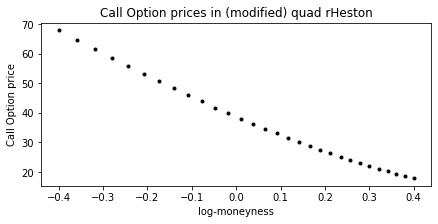

In [10]:
plt.figure(figsize=(7,3))
plt.plot(log_moneyness,Call_prices, 'k.')
#plt.plot(log_moneyness,Call_prices_fixedH, 'b+')
plt.xlabel('log-moneyness')
plt.ylabel('Call Option price')
plt.title('Call Option prices in (modified) quad rHeston')
plt.show()

## Import option price data

In [11]:
r,q = 0.,0.
S0 = 179.83

data = pd.read_csv('dataOptionPrices.csv')
def logstrike(S0,K,T): return np.log(K/S0*np.exp(-(r-q)*T))
data['LogStrike'] = [logstrike(S0,K,T) for K,T in zip(data['Strike'],data['Expiration'])]

data['IV'] = [impliedVolJaeckelRational(S0, K, c, T) for K,T,c in zip(data['Strike'],data['Expiration'],data['midPrice'])]

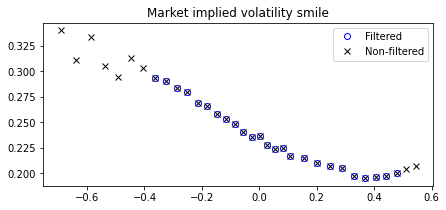

We use the filtered data for calibration only


In [12]:
ListMat = data["Expiration"].unique()
indexMat = -2 ## Select maturity index

df_filt = data[(data["Expiration"] == ListMat[indexMat]) & (data["IV"] >0.) & (data["IV"] <1.) & (data["LogStrike"] < 0.5) & (data["LogStrike"] > -0.4)]
df_nonfilt = data[data["Expiration"] == ListMat[indexMat]]

plt.figure(figsize=(7,3))
plt.plot(df_filt["LogStrike"].values, df_filt["IV"].values, "bo", mfc="None", label="Filtered")
plt.plot(df_nonfilt["LogStrike"].values, df_nonfilt["IV"].values, "kx", mfc="None", label="Non-filtered")
plt.title("Market implied volatility smile")
plt.legend(loc="best")
plt.show()
print("We use the filtered data for calibration only")

In [13]:
ivs_market = df_filt["IV"].values
strikes = df_filt["Strike"].values
T = ListMat[indexMat]

### Calibration on Call prices (fixed H)

In [14]:
def lossFunction_prices_fixedH(params, rde, strikes, dispPrint=False):
    """
    Loss function: we consider the L2 error
    """
    rde = RDE_QuadHeston(grid_points, epsilon, M, T, H, S0)
    rde.run__init__()
    
    callPrices = rde.callPrice_RDE_QuadHeston_MC(params, strikes)
    normError = np.sum([((a-b)/S0)**2 for (a,b) in zip(callPrices, prices_market)])
    
    if dispPrint:
        print("L2 error: ", np.round(normError, 5), "| Parameters: ", [np.round(p, 5) for p in params])
    return normError

In [15]:
H, kappa, M = 0.1, 1, 10000
S0 = 179.83
T = 1.

epsilon = 0.01

grid_points = 100
#nbPaths = 20000
prices_market = df_filt["midPrice"]
#  = 0.384, 0.095,0.0025,0.1,1.2, 1.
calibBounds_noH = ((0.1,0.5),(0.01,0.2),(0.0005,0.01),(0.05,0.5),(0.5,1.5),(0.5,1.5))


rde = RDE_QuadHeston(grid_points, epsilon, M, T, H, S0)

In [41]:
nb_init_test = 20
loss_best_init = 1
#a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,1.2,1.#1., 0.5, 1., 2., 0.2, 0.4
a, b, c, theta, lam, eta = 0.1, 0.4,0.05,0.1,0.1,1.1

p_best_init = a, b, c, theta, lam, eta


for i in range(nb_init_test):
    a = np.random.rand()*(calibBounds_noH[0][1] - calibBounds_noH[0][0])  + calibBounds_noH[0][0]
    b = np.random.rand()*(calibBounds_noH[1][1] - calibBounds_noH[1][0])  + calibBounds_noH[1][0]
    c = np.random.rand()*(calibBounds_noH[2][1] - calibBounds_noH[2][0])  + calibBounds_noH[2][0]
    theta = np.random.rand()*(calibBounds_noH[3][1] - calibBounds_noH[3][0])  + calibBounds_noH[3][0]
    lam = 1.2 #np.random.rand()*(calibBounds_noH[4][1] - calibBounds_noH[4][0])  + calibBounds_noH[4][0]
    eta = 1 #np.random.rand()*(calibBounds_noH[5][1] - calibBounds_noH[5][0])  + calibBounds_noH[5][0]
    
    params = a, b, c, theta, lam, eta
    currentLoss = lossFunction_prices_fixedH(params, rde, strikes, dispPrint=True)
    if loss_best_init > currentLoss:
        p_best_init = params
        loss_best_init = currentLoss

print("L2 error: ", np.round(loss_best_init, 5), "| Parameters: ", [np.round(p, 5) for p in p_best_init])
    

L2 error:  0.06975 | Parameters:  [np.float64(0.19775), np.float64(0.17303), np.float64(0.00331), np.float64(0.29083), np.float64(1.2), np.int64(1)]
L2 error:  0.08679 | Parameters:  [np.float64(0.19419), np.float64(0.11085), np.float64(0.004), np.float64(0.43433), np.float64(1.2), np.int64(1)]
L2 error:  0.29332 | Parameters:  [np.float64(0.30807), np.float64(0.17056), np.float64(0.00843), np.float64(0.28781), np.float64(1.2), np.int64(1)]
L2 error:  0.03228 | Parameters:  [np.float64(0.14876), np.float64(0.17971), np.float64(0.00126), np.float64(0.15632), np.float64(1.2), np.int64(1)]
L2 error:  nan | Parameters:  [np.float64(0.48755), np.float64(0.18237), np.float64(0.00361), np.float64(0.43826), np.float64(1.2), np.int64(1)]


KeyboardInterrupt: 

In [16]:
print("Optimal stating point:")
loss_best = lossFunction_prices_fixedH(p_best_init, rde, strikes, dispPrint=True)

Optimal stating point:


NameError: name 'p_best_init' is not defined

In [17]:
optim = minimize(lossFunction_prices_fixedH, p_best_init, args=(rde, strikes, True), method='L-BFGS-B', bounds=calibBounds_noH, tol=1E-2)
optimal_param_noH = optim.x
print("Calibration completed")

NameError: name 'p_best_init' is not defined

In [18]:
print("Initial parameters: ", [np.round(p, 4) for p in p_best_init])
print("Optimal parameters: ", [np.round(p, 4) for p in optimal_param_noH])

NameError: name 'p_best_init' is not defined

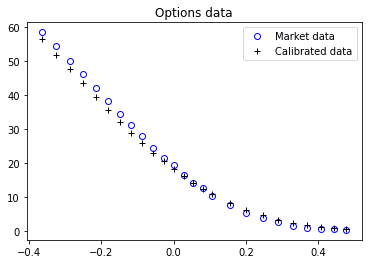

In [19]:
#a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,0.1,1.5#1., 0.5, 1., 2., 0.2, 0.4
a, b, c, theta, lam, eta = 0.075, 0.75,0.06,0.1,0.1,1.1
#a, b, c, theta, lam, eta = 0.1, 0.15,0.05,0.1,0.1,1.1

optimal_param_noH = a, b, c, theta, lam, eta


rde = RDE_QuadHeston(grid_points, epsilon, M, T, H,S0)
rde.run__init__()
callPrices_noH = rde.callPrice_RDE_QuadHeston_MC(optimal_param_noH, strikes)
#callPrices_noH = rde.callPrice_RDE_QuadHeston_MC(p_best_init, strikes)

plt.plot(df_filt["LogStrike"], prices_market, 'bo', mfc="None", label="Market data")
plt.plot(df_filt["LogStrike"], callPrices_noH, 'k+', label="Calibrated data")
plt.legend(loc="best")
plt.title("Options data")
plt.show()

/Users/obonesin/Documents/GitHub/rough-vol-rough-paths/Jackels.py:539: RuntimeWarning: overflow encountered in cast
  while (iterations < N and abs(ds) > DBL_EPSILON * s):
/Users/obonesin/Documents/GitHub/rough-vol-rough-paths/Jackels.py:540: RuntimeWarning: overflow encountered in cast
  if (ds * ds_previous < 0):


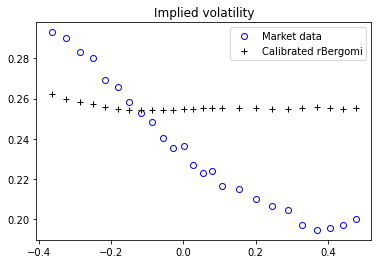

In [20]:
ivs_calibrated = rde.implied_vol(optimal_param_noH, strikes)

plt.plot(df_filt["LogStrike"].values, ivs_market, 'bo', mfc="None", label="Market data")
plt.plot(df_filt["LogStrike"].values, ivs_calibrated, 'k+', label="Calibrated rBergomi")
plt.legend(loc="best")
plt.title("Implied volatility")
plt.show()
plt.show()

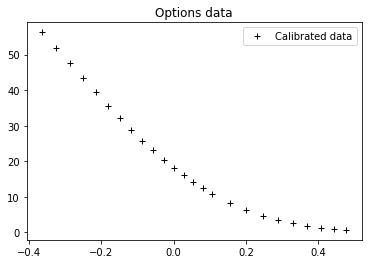

In [21]:
plt.plot(df_filt["LogStrike"], callPrices_noH, 'k+', label="Calibrated data")
plt.legend(loc="best")
plt.title("Options data")
plt.show()